Exploratory Statistical Analysis of Daily Stock Returns – A Descriptive Statistics Perspective

In [ ]:
!pip install yfinance

In [4]:
#Importing libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [14]:
#Downloading historical data
stock = "TATASTEEL.NS"
data = yf.download(stock, start="2020-01-01", end="2025-01-01")
print(data.head(7))

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker     TATASTEEL.NS TATASTEEL.NS TATASTEEL.NS TATASTEEL.NS TATASTEEL.NS
Date                                                                       
2020-01-01    39.250175    39.984412    39.002631    39.690715    121005300
2020-01-02    40.685081    40.932622    39.606803    39.606803    216749610
2020-01-03    40.588581    40.798363    40.231953    40.529842    129568630
2020-01-06    39.711697    40.278107    39.485132    40.278107     96016080
2020-01-07    39.950848    40.664104    39.736869    39.900499    131957880
2020-01-08    39.879520    40.122865    39.187240    39.577434    133048410
2020-01-09    40.542431    40.781582    40.202585    40.697671    101311520


In [15]:
#Calculating daily returns
data['Return'] = data['Close'].pct_change()
returns = data['Return'].dropna()
print(returns.head())

Date
2020-01-02    0.036558
2020-01-03   -0.002372
2020-01-06   -0.021604
2020-01-07    0.006022
2020-01-08   -0.001785
Name: Return, dtype: float64


In [17]:
#Calculating Descriptives
mean_return = returns.mean()
median_return = returns.median()
std_dev = returns.std()
skewness = returns.skew()
kurtosis = returns.kurt()
min_return = returns.min()
max_return = returns.max()
quantiles = returns.quantile([0.05, 0.95])

print("Mean:", mean_return)
print("Median:", median_return)
print("Volatility (Std Dev):", std_dev)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)
print("5% Quantile:", quantiles[0.05])
print("95% Quantile:", quantiles[0.95])

Mean: 0.001279599683236293
Median: 0.001307808045942771
Volatility (Std Dev): 0.02369086140443098
Skewness: -0.11564619313215391
Kurtosis: 3.602803780466712
5% Quantile: -0.03599441071513227
95% Quantile: 0.03934266716228314


Interpretation-

The return series exhibits a small positive average with volatility significantly larger than the mean, indicating that short-term fluctuations dominate daily behavior.

Skewness is close to zero, suggesting approximate symmetry with no strong bias toward extreme gains or losses.

However, the high excess kurtosis indicates frequent extreme movements relative to a normal benchmark, implying meaningful tail risk in the return distribution.

The upper and lower quantiles are relatively close in magnitude, indicating that extreme positive and negative movements are fairly balanced. This aligns with the near-zero skewness observed earlier.

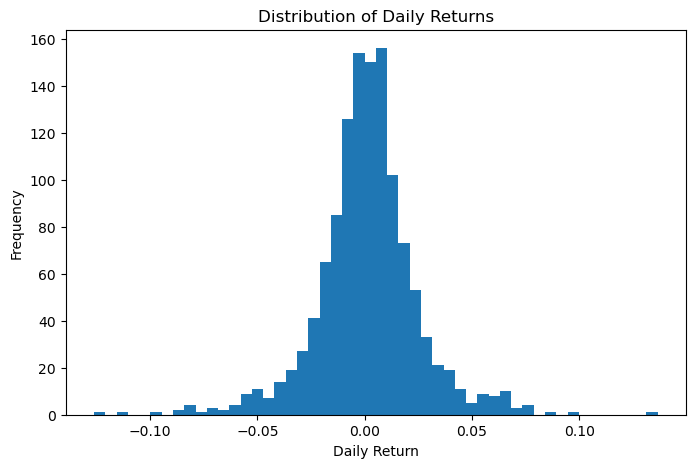

In [19]:
#Visualizing the data
plt.figure(figsize=(8,5))
plt.hist(returns, bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Interpretation -

The histogram indicates that daily returns are highly concentrated around zero, with most observations lying within a narrow range.

The distribution appears approximately symmetric, consistent with the near-zero skewness observed earlier.

However, the presence of relatively frequent extreme values on both ends suggests heavy tails. This visual evidence supports the high excess kurtosis calculated previously, indicating that extreme movements occur more often than predicted by a normal distribution.

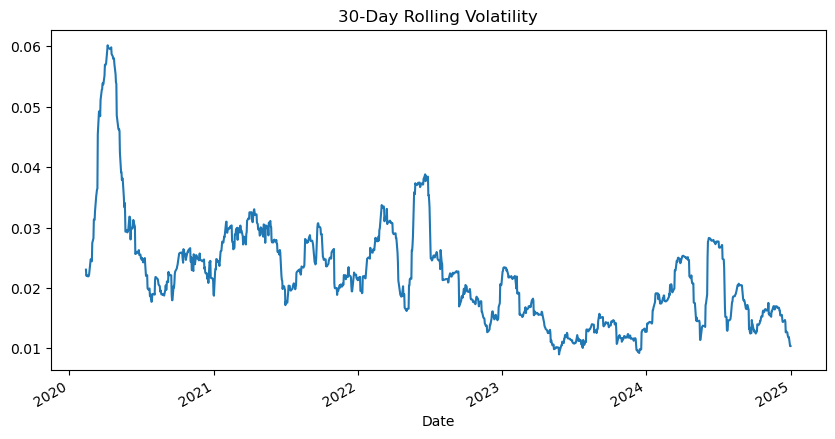

In [21]:
#Rolling volatility
rolling_vol = returns.rolling(window=30).std()

plt.figure(figsize=(10,5))
rolling_vol.plot()
plt.title("30-Day Rolling Volatility")
plt.show()

Interpretation -

The plot reveals significant variation in risk over time. A major spike is observed during early 2020, indicating a period of extreme market instability.

Volatility appears to cluster, with high-volatility periods persisting before gradually reverting to lower levels after 2022.

In more recent years, volatility has remained comparatively moderate. Overall, the evidence suggests that the return series exhibits time-varying volatility rather than constant variance.

Conclusion - 

The analysis indicates that daily returns are centered around a small positive mean but are dominated by short-term fluctuations.While the distribution appears broadly symmetric, the histogram and high kurtosis reveal the presence of occasional extreme movements. The rolling volatility plot further shows that risk levels are not constant over time, with clear periods of elevated and subdued volatility. Together, these findings suggest that the return series is stable in direction but variable in risk intensity.